In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# F = kd
# w = z - d

# F = 4/3 E/(1-nu^2) * sqrt(R) (w)^(3/2)


nu = 0.5
R_1 = 2.5e-6 #um
R_2 = 5.0e-6

w_1 = 0.1 * R_1 # um
z_1 = 2.0 * w # 0.5 um
d_1 = w # 0.25 um

w_2 = 0.1 * R_2 # um
z_2 = 2.0 * w # 0.5 um
d_2 = w # 0.25 um


E = np.linspace(1, 100e3, 100)
k_1 = 4.0 * 3.0 / (1 - nu * nu) * np.sqrt(R_1) * np.pow(w_1, 3.0 / 2.0) / d_1 * E
k_2 = 4.0 * 3.0 / (1 - nu * nu) * np.sqrt(R_2) * np.pow(w_2, 3.0 / 2.0) / d_2 * E

print(np.log10(0.1))
print(np.log10(0.01))

plt.rcParams.update({'font.size': 16})

fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_xscale('log')
ax.set_yscale('log')
plt.grid(True)
plt.plot(E/1e3, k_1, 'r-')
plt.plot(E/1e3, k_2, 'b-')
plt.legend(['R = 2.5 um', 'R = 5 um'])
# plt.axvline(x=np.log10(1))
# plt.axhline(y=np.log10(0.1))
# plt.axhline(y=np.log10(0.01))
# plt.axvline(x=np.log10(0.5))
plt.title("Cantilever Selection")
plt.xlabel("Expected Young's Modulus E [kPa]")
plt.ylabel("Cantilever stiffness k [N/m]")
plt.show()

NameError: name 'w' is not defined

*Node
1, 0.00000000, 50.00000000, 0.00000000
2, 1.11111111, 50.00000000, 0.00000000
3, 2.22222222, 50.00000000, 0.00000000
4, 3.33333333, 50.00000000, 0.00000000
5, 4.44444444, 50.00000000, 0.00000000
6, 5.55555556, 50.00000000, 0.00000000
7, 6.66666667, 50.00000000, 0.00000000
8, 7.77777778, 50.00000000, 0.00000000
9, 8.88888889, 50.00000000, 0.00000000
10, 10.00000000, 50.00000000, 0.00000000
11, 0.00000000, 55.00000000, 0.00000000
12, 0.86824089, 55.07596123, 0.00000000
13, 1.71010072, 55.30153690, 0.00000000
14, 2.50000000, 55.66987298, 0.00000000
15, 3.21393805, 56.16977778, 0.00000000
16, 3.83022222, 56.78606195, 0.00000000
17, 4.33012702, 57.50000000, 0.00000000
18, 4.69846310, 58.28989928, 0.00000000
19, 4.92403877, 59.13175911, 0.00000000
20, 5.00000000, 60.00000000, 0.00000000


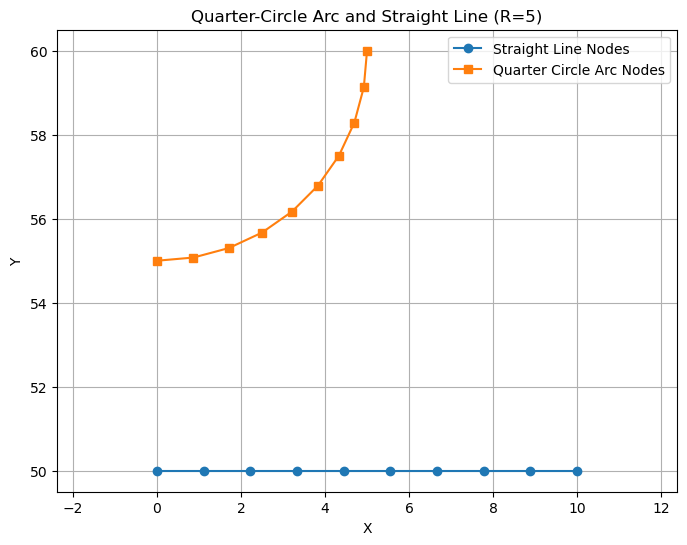

In [2]:
import numpy as np
from matplotlib import pyplot as plt

# Same number of nodes for line and arc
num_nodes = 10

# Line: X from 0 to 10, Y = 50
x_line = np.linspace(0, 10, num_nodes)
y_line = np.full_like(x_line, 50.0)
z_line = np.zeros_like(x_line)

# Arc: quarter circle from (0,55) to (5,60)
R = 5.0
theta = np.linspace(-np.pi/2, 0, num_nodes)
x_arc = R * np.cos(theta)            # From 0 to 5
y_arc = 60 + R * np.sin(theta)       # From 55 to 60
z_arc = np.zeros_like(x_arc)

# Combine both
x_all = np.concatenate([x_line, x_arc])
y_all = np.concatenate([y_line, y_arc])
z_all = np.concatenate([z_line, z_arc])

# Output Abaqus node list
print("*Node")
for i, (x, y, z) in enumerate(zip(x_all, y_all, z_all), start=1):
    print(f"{i}, {x:.8f}, {y:.8f}, {z:.8f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_line, y_line, 'o-', label="Straight Line Nodes")
plt.plot(x_arc, y_arc, 's-', label="Quarter Circle Arc Nodes")
plt.axis('equal')
plt.grid(True)
plt.title("Quarter-Circle Arc and Straight Line (R=5)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


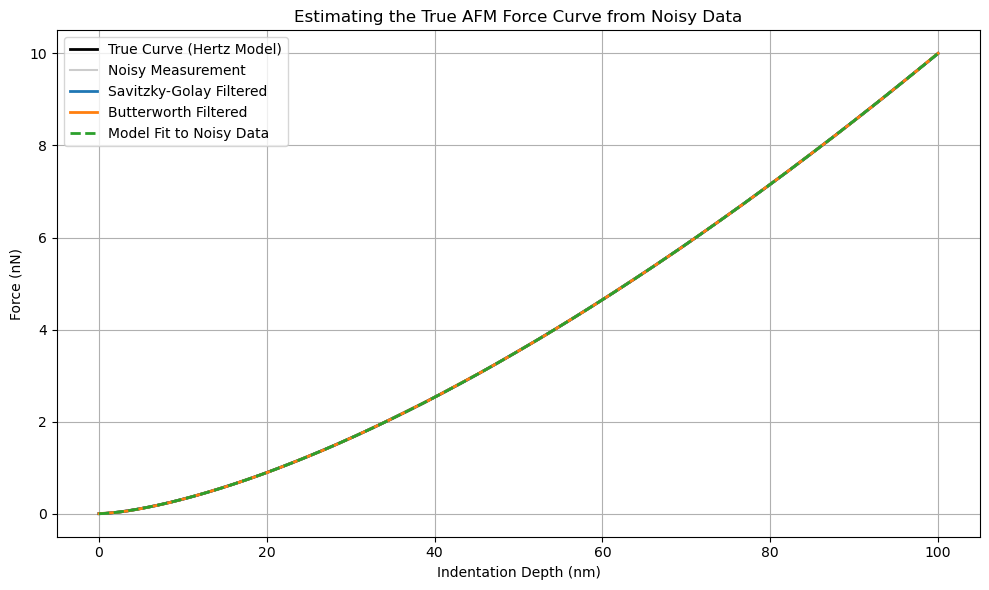

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, butter, filtfilt
from scipy.optimize import curve_fit

# Simulated Hertzian contact model: F = A * d^1.5
def hertz_model(d, A):
    return A * d**1.5

# Generate true signal
np.random.seed(42)
indent = np.linspace(0, 100, 500)  # nm
A_true = 0.01  # contact stiffness coefficient
force_true = hertz_model(indent, A_true)

# Add synthetic Gaussian noise
noise_level = 0.005  # nN
force_noisy = force_true + np.random.normal(0, noise_level, size=indent.size)

# Apply Savitzky-Golay filter
force_savgol = savgol_filter(force_noisy, window_length=31, polyorder=3)

# Apply Butterworth filter
b, a = butter(N=2, Wn=0.1)
force_butter = filtfilt(b, a, force_noisy)

# Fit Hertz model to noisy data
fit_mask = indent > 10  # ignore near-zero values where noise dominates
popt, _ = curve_fit(hertz_model, indent[fit_mask], force_noisy[fit_mask], p0=[0.01])
force_fit = hertz_model(indent, *popt)

# Plot everything
plt.figure(figsize=(10, 6))
plt.plot(indent, force_true, label="True Curve (Hertz Model)", linewidth=2, color='black')
plt.plot(indent, force_noisy, label="Noisy Measurement", alpha=0.4, color='gray')
plt.plot(indent, force_savgol, label="Savitzky-Golay Filtered", linewidth=2)
plt.plot(indent, force_butter, label="Butterworth Filtered", linewidth=2)
plt.plot(indent, force_fit, label="Model Fit to Noisy Data", linestyle='--', linewidth=2)

plt.xlabel("Indentation Depth (nm)")
plt.ylabel("Force (nN)")
plt.title("Estimating the True AFM Force Curve from Noisy Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
